### ORP Exploring Data

### Setup

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

In [2]:
output_dir = '../images'
os.makedirs(output_dir, exist_ok=True)

In [3]:
def save_plot(fig, filename):
    file_path = os.path.join(output_dir, filename)
    fig.savefig(file_path, bbox_inches='tight')
    print(f'Image saved as {file_path}')

#### Recovering the data

In [4]:
import pandas as pd
import seaborn as sns

In [5]:
ML_ROOT_DIR = "../../ml-models"
FOLDER_ID = "datasets"
LDD_PATH = os.path.join(ML_ROOT_DIR, FOLDER_ID)

In [6]:
def load_orpe_data(ldd_path = LDD_PATH):
  csv_path = os.path.join(ldd_path, 'OsteoporosisRiskPrediction.csv')
  return pd.read_csv(csv_path)

#### Understanding the data structure

In [7]:
orpe = pd.read_csv('../ORP/OsteoporosisRiskPrediction.csv')

In [8]:
orpe.head()

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,1734616,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,1419098,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,1797916,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,1805337,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,1351334,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1


In [9]:
orpe.columns

Index(['Id', 'Age', 'Gender', 'Hormonal Changes', 'Family History',
       'Race/Ethnicity', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake',
       'Physical Activity', 'Smoking', 'Alcohol Consumption',
       'Medical Conditions', 'Medications', 'Prior Fractures', 'Osteoporosis'],
      dtype='object')

In [10]:
# Removing unnecessary columns
orpe = orpe.drop(columns=['Id'])

In [11]:
orpe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Age                  1958 non-null   int64 
 1   Gender               1958 non-null   object
 2   Hormonal Changes     1958 non-null   object
 3   Family History       1958 non-null   object
 4   Race/Ethnicity       1958 non-null   object
 5   Body Weight          1958 non-null   object
 6   Calcium Intake       1958 non-null   object
 7   Vitamin D Intake     1958 non-null   object
 8   Physical Activity    1958 non-null   object
 9   Smoking              1958 non-null   object
 10  Alcohol Consumption  970 non-null    object
 11  Medical Conditions   1311 non-null   object
 12  Medications          973 non-null    object
 13  Prior Fractures      1958 non-null   object
 14  Osteoporosis         1958 non-null   int64 
dtypes: int64(2), object(13)
memory usage: 229.6+ KB


In [12]:
# Visualizing the distribution of the target variable
orpe['Osteoporosis'].value_counts()

Osteoporosis
1    979
0    979
Name: count, dtype: int64

In [13]:
orpe.describe()

,Age,Osteoporosis
count,1958.000000,1958.000000
mean,39.101124,0.500000
std,21.355424,0.500128
min,18.000000,0.000000
25%,21.000000,0.000000
50%,32.000000,0.500000
75%,53.000000,1.000000
max,90.000000,1.000000


In [14]:
# histogram for numeric attributes
%matplotlib inline
import matplotlib.pyplot as plt

In [15]:
na_counts = orpe.isna().sum().sort_values(ascending=False)
print("Valores ausentes por coluna:\n", na_counts)

Valores ausentes por coluna:
 Alcohol Consumption    988
Medications            985
Medical Conditions     647
Family History           0
Age                      0
Gender                   0
Hormonal Changes         0
Calcium Intake           0
Body Weight              0
Race/Ethnicity           0
Vitamin D Intake         0
Smoking                  0
Physical Activity        0
Prior Fractures          0
Osteoporosis             0
dtype: int64


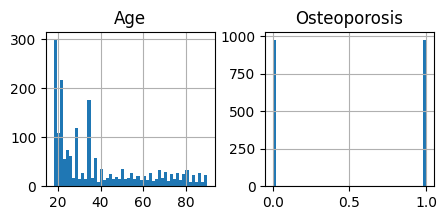

In [16]:
# histogram for numeric attributes
orpe.hist(bins=50, figsize=(5, 2))
plt.show()

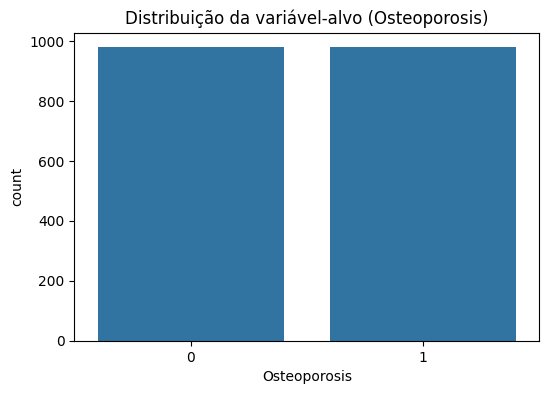

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=orpe, x="Osteoporosis")
plt.title("Distribuição da variável-alvo (Osteoporosis)")
plt.show()

In [18]:
numerical_cols = orpe.select_dtypes(include=np.number).columns

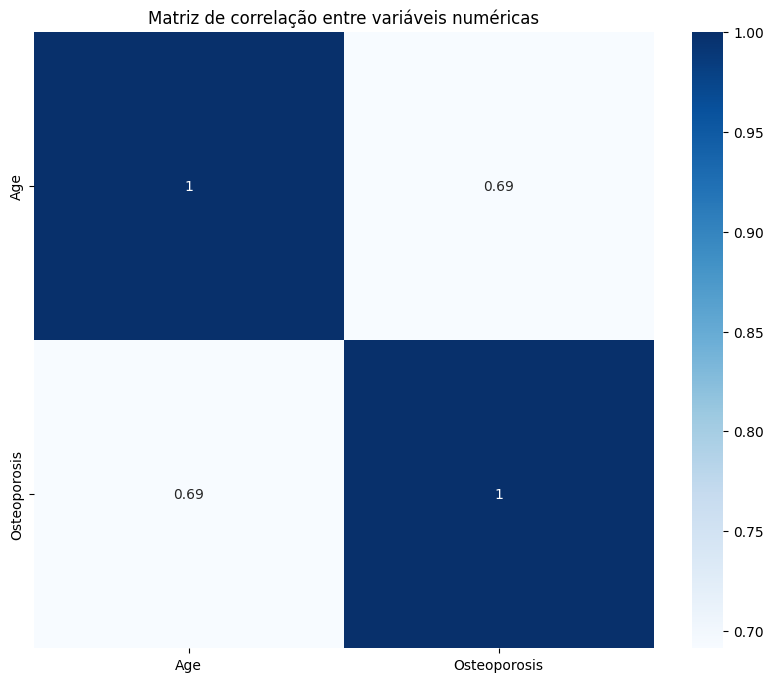

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(orpe[numerical_cols].corr(), annot=True, cmap="Blues")
plt.title("Matriz de correlação entre variáveis numéricas")
plt.show()

#### Handling missing values

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

target_col = "Osteoporosis"

# separa features e alvo antes do preprocessamento
X_raw = orpe.drop(columns=[target_col]).copy()
y_raw = orpe[target_col].copy()

numeric_features = X_raw.select_dtypes(include=["number"]).columns
categorical_features = X_raw.select_dtypes(include=["object", "category", "bool"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# compatível com versões diferentes do sklearn
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X_processed = preprocessor.fit_transform(X_raw)
feature_names = preprocessor.get_feature_names_out()

X_processed_df = pd.DataFrame(X_processed, columns=feature_names, index=X_raw.index)

# target string -> numérico
label_encoder = LabelEncoder()
y_processed = pd.Series(
    label_encoder.fit_transform(y_raw.astype(str)),
    name=target_col,
    index=y_raw.index
)

orpe_preprocessed = pd.concat([X_processed_df, y_processed], axis=1)

print("Shape final:", orpe_preprocessed.shape)
print("Mapeamento target:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Shape final: (1958, 27)
Mapeamento target: {'0': np.int64(0), '1': np.int64(1)}


In [21]:
orpe_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 27 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   num__Age                                      1958 non-null   float64
 1   cat__Gender_Female                            1958 non-null   float64
 2   cat__Gender_Male                              1958 non-null   float64
 3   cat__Hormonal Changes_Normal                  1958 non-null   float64
 4   cat__Hormonal Changes_Postmenopausal          1958 non-null   float64
 5   cat__Family History_No                        1958 non-null   float64
 6   cat__Family History_Yes                       1958 non-null   float64
 7   cat__Race/Ethnicity_African American          1958 non-null   float64
 8   cat__Race/Ethnicity_Asian                     1958 non-null   float64
 9   cat__Race/Ethnicity_Caucasian                 1958 non-null   f

In [22]:
orpe_preprocessed.head()

,num__Age,cat__Gender_Female,cat__Gender_Male,cat__Hormonal Changes_Normal,cat__Hormonal Changes_Postmenopausal,cat__Family History_No,cat__Family History_Yes,cat__Race/Ethnicity_African American,cat__Race/Ethnicity_Asian,cat__Race/Ethnicity_Caucasian,...,cat__Physical Activity_Sedentary,cat__Smoking_No,cat__Smoking_Yes,cat__Alcohol Consumption_Moderate,cat__Medical Conditions_Hyperthyroidism,cat__Medical Conditions_Rheumatoid Arthritis,cat__Medications_Corticosteroids,cat__Prior Fractures_No,cat__Prior Fractures_Yes,Osteoporosis
0,69.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1
1,32.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1
2,89.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1
3,78.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1
4,38.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1


In [23]:
orpe_preprocessed.describe()

,num__Age,cat__Gender_Female,cat__Gender_Male,cat__Hormonal Changes_Normal,cat__Hormonal Changes_Postmenopausal,cat__Family History_No,cat__Family History_Yes,cat__Race/Ethnicity_African American,cat__Race/Ethnicity_Asian,cat__Race/Ethnicity_Caucasian,...,cat__Physical Activity_Sedentary,cat__Smoking_No,cat__Smoking_Yes,cat__Alcohol Consumption_Moderate,cat__Medical Conditions_Hyperthyroidism,cat__Medical Conditions_Rheumatoid Arthritis,cat__Medications_Corticosteroids,cat__Prior Fractures_No,cat__Prior Fractures_Yes,Osteoporosis
count,1958.000000,1958.000000,1958.000000,1958.000000,1958.000000,1958.000000,1958.000000,1958.000000,1958.000000,1958.000000,...,1958.000000,1958.000000,1958.000000,1958.0,1958.000000,1958.000000,1958.0,1958.000000,1958.000000,1958.000000
mean,39.101124,0.493361,0.506639,0.501021,0.498979,0.509704,0.490296,0.347804,0.322268,0.329928,...,0.478550,0.498468,0.501532,1.0,0.676711,0.323289,1.0,0.497957,0.502043,0.500000
std,21.355424,0.500084,0.500084,0.500127,0.500127,0.500034,0.500034,0.476395,0.467464,0.470307,...,0.499667,0.500125,0.500125,0.0,0.467852,0.467852,0.0,0.500124,0.500124,0.500128
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
25%,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
50%,32.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.0,1.000000,0.000000,1.0,0.000000,1.000000,0.500000
75%,53.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000
max,90.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000


### Saving the dataset

In [24]:
from pathlib import Path
from sklearn.model_selection import train_test_split

target_col = "Osteoporosis"
X = orpe_preprocessed.drop(columns=[target_col])
y = orpe_preprocessed[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_df = pd.concat([X_train, y_train.rename(target_col)], axis=1)
max_count = train_df[target_col].value_counts().max()

train_balanced_df = (
    train_df.groupby(target_col, group_keys=False)
    .apply(lambda g: g.sample(max_count, replace=True, random_state=42))
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

X_train_bal = train_balanced_df.drop(columns=[target_col])
y_train_bal = train_balanced_df[target_col]

out_dir = Path("../../datasets/orp_datasets")
out_dir.mkdir(parents=True, exist_ok=True)

orpe_preprocessed.to_csv(out_dir / "orp_preprocessed.csv", index=False)

X_train.to_csv(out_dir / "X_train_unbalanced.csv", index=False)
X_test.to_csv(out_dir / "X_test.csv", index=False)
y_train.to_frame(name=target_col).to_csv(out_dir / "y_train_unbalanced.csv", index=False)
y_test.to_frame(name=target_col).to_csv(out_dir / "y_test.csv", index=False)

X_train_bal.to_csv(out_dir / "X_train_balanced.csv", index=False)
y_train_bal.to_frame(name=target_col).to_csv(out_dir / "y_train_balanced.csv", index=False)

print(f"✔ Arquivos salvos em: {out_dir.resolve()}")
print("✔ Train desbalanceado: X_train_unbalanced.csv / y_train_unbalanced.csv")
print("✔ Train balanceado: X_train_balanced.csv / y_train_balanced.csv")
print("✔ Teste: X_test.csv / y_test.csv")

✔ Arquivos salvos em: C:\Users\luizf\Desktop\osteoporosis\root\ml-models\datasets\orp_datasets
✔ Train desbalanceado: X_train_unbalanced.csv / y_train_unbalanced.csv
✔ Train balanceado: X_train_balanced.csv / y_train_balanced.csv
✔ Teste: X_test.csv / y_test.csv


C:\Users\luizf\AppData\Local\Temp\ipykernel_14620\2280621246.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(max_count, replace=True, random_state=42))
